In [3]:
import pandas as pd
from tours import config, dataset, metrics
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from numpy import log
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib as plt

In [4]:
df = dataset.load_clean_data()
df = dataset.cutoff_series(df)
train, val, split = dataset.split_data(df)

ValueError: cannot reindex on an axis with duplicate labels

Before testing an ARIMA model, I need to see if the time series is stationary to determine the differencing term. If the series is stationary then no differencing term is needed and d=0 in the model parameters. I'll do this using the augmented Dickey-Fuller test.

The null hypothesis of the ADF test is that the time series is non-stationary. So, if the p-value of the test is less than the significance level (0.05) then reject the null hypothesis and infer that the time series is stationary.

ADF Statistic: -2.989936
p-value: 0.035845
The series is stationary


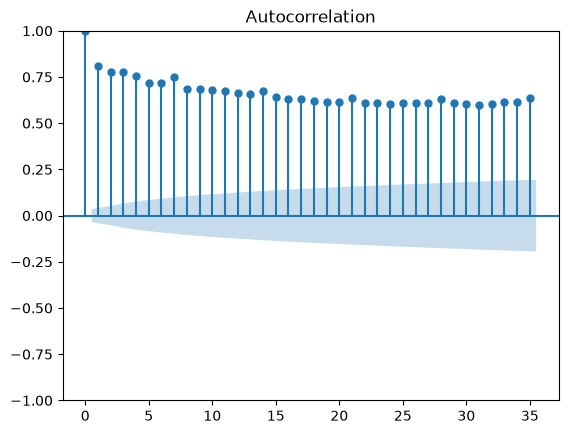

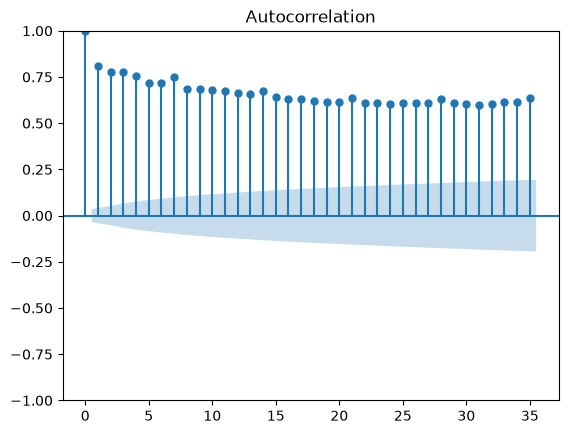

In [ ]:
result = adfuller(df["headcount"].dropna(), result_object=False)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print(f'The series is stationary' if result[1] < 0.05 else 'The series is non-stationary')

plot_acf(df["headcount"])

The ADF test returned a p-value of 0.036, marginally rejecting the unit-root null and suggesting stationarity, while the ACF shows autocorrelation persisting above 0.6 out to lag 35 — a pattern normally associated with non-stationarity. This discrepancy is most likely driven by the structural break in the series: the ~22-month COVID shutdown (March 2020–January 2022), during which attendance sat near zero, inflates autocorrelation at nearly every lag because a large share of value pairs are jointly near zero regardless of true lag dependence. Standard ADF assumes a single data-generating process across the full sample and is known to behave erratically in the presence of structural breaks, so a p-value this close to the 0.05 threshold carries little diagnostic weight here. 

I'll test stationarity on the post-2022 segment to see what the behaviour is. Potentially i will need to isolate my model to post covid recovery, or use a model that can take into account the large break in values

In [ ]:
df.columns

Index(['tour_year', 'tour_month', 'tour_day', 'day_name', 'day_of_week',
       'num_guides', 'headcount', 'covid_flag', 'xmas_flag', 'source'],
      dtype='str')

ADF Statistic: -5.847073
p-value: 0.000000
The series is stationary


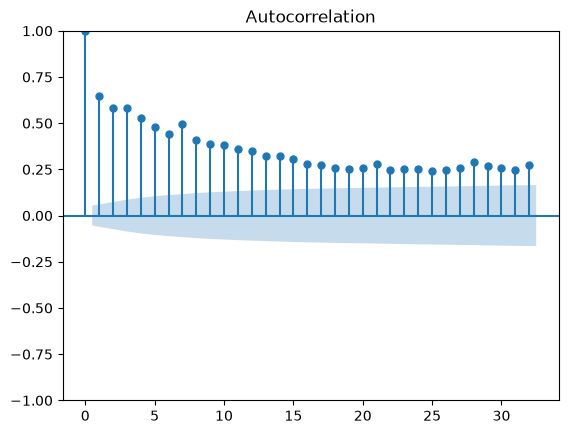

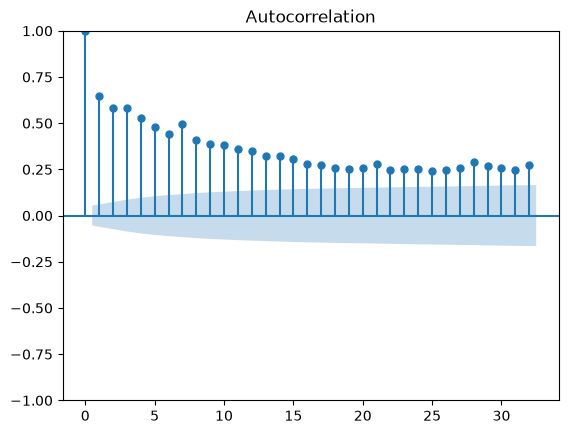

In [ ]:
df_post22 = df[df["tour_year"]>2022]["headcount"]
result_post22 = adfuller(df_post22.dropna(), result_object=False)
print('ADF Statistic: %f' % result_post22[0])
print('p-value: %f' % result_post22[1])
print(f'The series is stationary' if result_post22[1] < 0.05 else 'The series is non-stationary')

# fig, ax = plt.subplots()
# plot_acf(df_post22, ax=ax)
# plt.show()

plot_acf(df_post22)

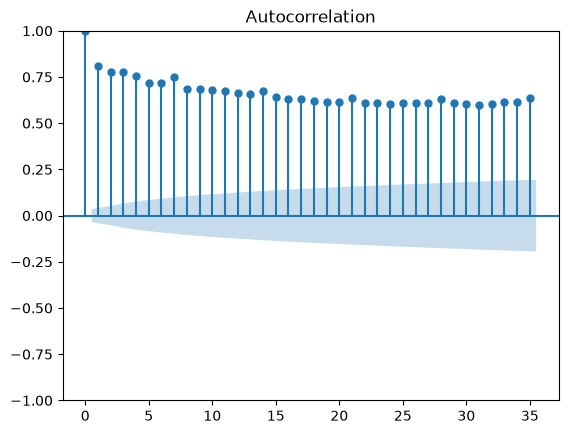

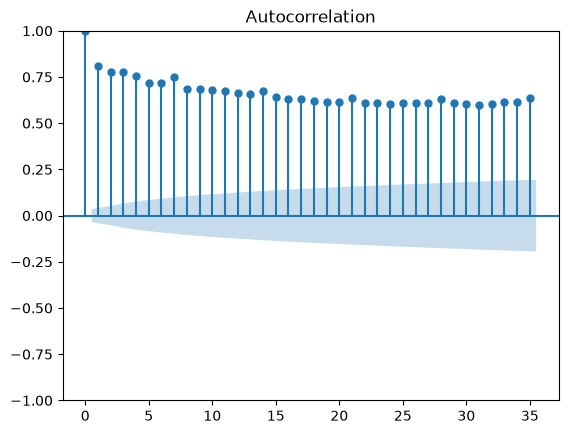

In [ ]:
plot_acf(df["headcount"])

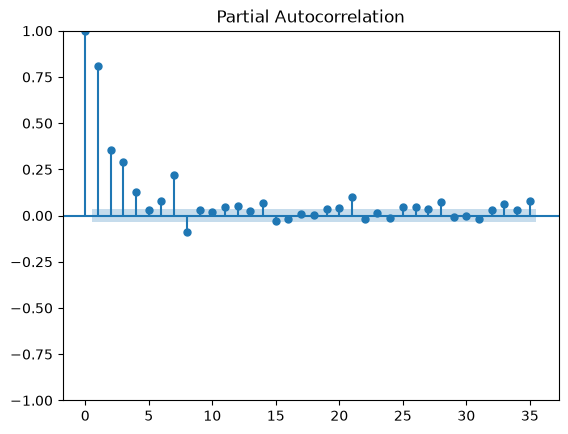

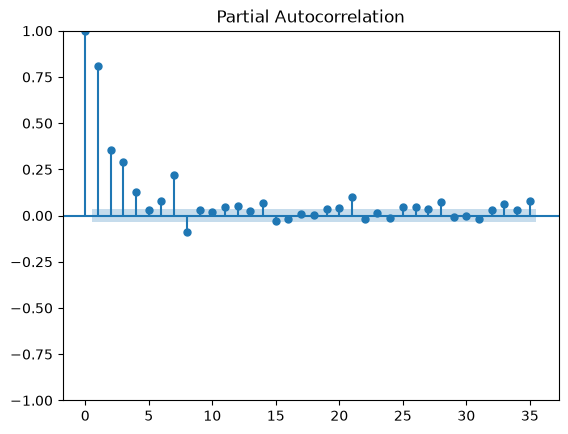

In [ ]:
plot_pacf(df["headcount"])